# HW_DT_GB

Сравнение моделей для задачи кредитного дефолта.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

train = pd.read_csv('course_project_train.csv')
test  = pd.read_csv('course_project_test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()


Train shape: (7500, 17)
Test shape:  (2500, 16)


,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0


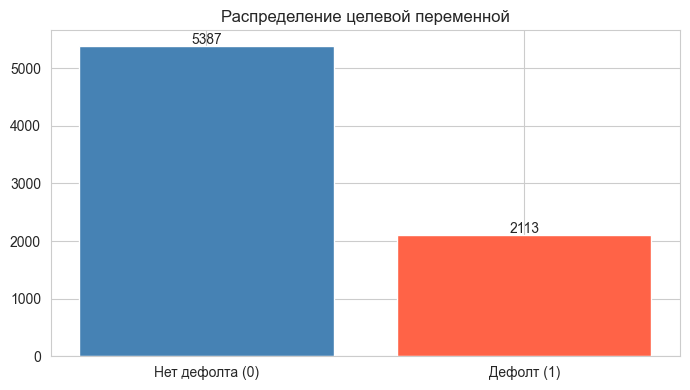

Пропуски (%):
Months since last delinquent    54.4
Credit Score                    20.8
Annual Income                   20.8
Years in current job             4.9
Bankruptcies                     0.2
Purpose                          0.0
Monthly Debt                     0.0
Current Credit Balance           0.0
dtype: float64


In [2]:
TARGET = 'Credit Default'
counts = train[TARGET].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(['Нет дефолта (0)', 'Дефолт (1)'], counts.values, color=['steelblue', 'tomato'])
plt.title('Распределение целевой переменной')
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha='center')
plt.tight_layout()
plt.show()

print('Пропуски (%):')
print((train.isnull().mean() * 100).sort_values(ascending=False).round(1).head(8))

def basic_clean(df):
    df = df.copy()

    if 'Current Loan Amount' in df.columns:
        df.loc[df['Current Loan Amount'] == 99999999, 'Current Loan Amount'] = np.nan

    if 'Years in current job' in df.columns:
        mapping = {
            '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
            '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
            '10+ years': 10
        }
        df['Years in current job'] = df['Years in current job'].replace(mapping).astype(float)

    return df

def add_features(df):
    df = df.copy()

    ai = pd.to_numeric(df['Annual Income'], errors='coerce')
    md = pd.to_numeric(df['Monthly Debt'], errors='coerce')
    ccb = pd.to_numeric(df['Current Credit Balance'], errors='coerce')
    moc = pd.to_numeric(df['Maximum Open Credit'], errors='coerce')
    noa = pd.to_numeric(df['Number of Open Accounts'], errors='coerce')
    mdel = pd.to_numeric(df['Months since last delinquent'], errors='coerce')

    df['Debt_to_Income'] = md * 12 / (ai + 1)
    df['Credit_Utilization'] = ccb / (moc + 1)
    df['Debt_per_Account'] = md / (noa + 1)
    df['Has_Delinquent'] = (~mdel.isna()).astype(int)

    return df

train = add_features(basic_clean(train))
test = add_features(basic_clean(test))

In [3]:
X = train.drop(columns=['Credit Default'])
y = train['Credit Default'].astype(int)

cat_cols = [c for c in X.columns if pd.api.types.is_string_dtype(X[c]) or X[c].dtype == 'object']
num_cols = [c for c in X.columns if c not in cat_cols]

print('Категориальные признаки:', cat_cols)
print('Числовых признаков:', len(num_cols))

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sw_train = compute_sample_weight('balanced', y_train)

pre_lr = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

pre_tree = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

Категориальные признаки: ['Home Ownership', 'Purpose', 'Term']
Числовых признаков: 17


In [4]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocess', pre_lr),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', C=0.5))
    ]),
    'Decision Tree': Pipeline([
        ('preprocess', pre_tree),
        ('model', DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', pre_tree),
        ('model', RandomForestClassifier(
            n_estimators=400, max_depth=12, min_samples_leaf=4,
            class_weight='balanced', random_state=42, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocess', pre_tree),
        ('model', GradientBoostingClassifier(
            random_state=42, n_estimators=200, learning_rate=0.05, max_depth=3
        ))
    ])
}

fit_kwargs = {
    'Logistic Regression': {},
    'Decision Tree': {},
    'Random Forest': {},
    'Gradient Boosting': {'model__sample_weight': sw_train}
}

In [5]:
results = []
best_model = None
best_name = None
best_threshold = None
best_f1 = -1

for name, model in models.items():
    model.fit(X_train, y_train, **fit_kwargs[name])
    proba = model.predict_proba(X_val)[:, 1]

    local_best_f1 = -1
    local_best_threshold = 0.5

    for t in np.linspace(0.15, 0.70, 111):
        pred = (proba >= t).astype(int)
        score = f1_score(y_val, pred)

        if score > local_best_f1:
            local_best_f1 = score
            local_best_threshold = float(t)

    results.append([name, round(local_best_f1, 4), round(local_best_threshold, 3)])

    if local_best_f1 > best_f1:
        best_f1 = local_best_f1
        best_threshold = local_best_threshold
        best_name = name
        best_model = model

results_df = pd.DataFrame(
    results, columns=['Model', 'F1_score', 'Best_threshold']
).sort_values('F1_score', ascending=False).reset_index(drop=True)

results_df

,Model,F1_score,Best_threshold
0,Gradient Boosting,0.5449,0.495
1,Random Forest,0.5388,0.440
2,Logistic Regression,0.5200,0.515
3,Decision Tree,0.5085,0.535


Лучшая модель: Gradient Boosting
Лучший F1: 0.5449
Лучший порог: 0.495


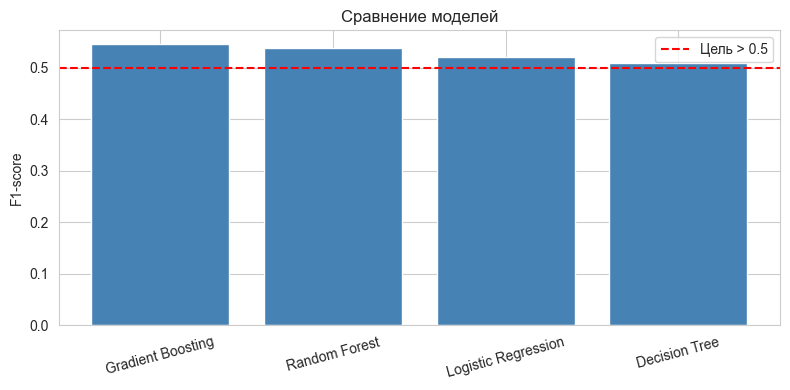

In [6]:
print('Лучшая модель:', best_name)
print('Лучший F1:', round(best_f1, 4))
print('Лучший порог:', round(best_threshold, 3))

plot_df = results_df.sort_values('F1_score', ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(plot_df['Model'], plot_df['F1_score'], color='steelblue')
plt.axhline(0.5, color='red', linestyle='--', label='Цель > 0.5')
plt.ylabel('F1-score')
plt.title('Сравнение моделей')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
if best_name == 'Gradient Boosting':
    sw_full = compute_sample_weight('balanced', y)
    best_model.fit(X, y, model__sample_weight=sw_full)
else:
    best_model.fit(X, y)

proba_test = best_model.predict_proba(test)[:, 1]
y_test_pred = (proba_test >= best_threshold).astype(int)

pd.DataFrame({'Credit Default': y_test_pred}).to_csv('predictions_only_target.csv', index=False)
pd.DataFrame({'id': range(len(y_test_pred)), 'Credit Default': y_test_pred}).to_csv('predictions.csv', index=False)

print('Файлы predictions_only_target.csv и predictions.csv сохранены')
print('Всего прогнозов:', len(y_test_pred))
print('Дефолт (1):', int(y_test_pred.sum()))
print('Нет дефолта (0):', int((1 - y_test_pred).sum()))

Файлы predictions_only_target.csv и predictions.csv сохранены
Всего прогнозов: 2500
Дефолт (1): 953
Нет дефолта (0): 1547


## Выводы

Сравнены Logistic Regression, Decision Tree, Random Forest и Gradient Boosting.

Лучшая модель выбирается по F1-score на валидации. После этого она обучается на всей обучающей выборке и используется для прогноза на тесте.

